### This notebook generates figure 1 of the Shahbazi et al. 2026 paper

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
import cortico_cereb_connectivity.globals as gl
import cortico_cereb_connectivity.scripts.script_plotting_utils as plu

#### import the .tsv files to plot

In [3]:
df_L2reg = pd.read_csv('../../tsv/L2reg_heatmap.tsv', sep='\t')
df_NNLS = pd.read_csv('../../tsv/NNLS_heatmap.tsv', sep='\t')
df_diff = pd.read_csv('../../tsv/Diff_heatmap.tsv', sep='\t')

ds_order = ["MDTB", "Language", "Social", "WMFS", "Demand", "Somatotopic", "Nishimoto", "IBC", "HCPur100"]

save_plots = True

#### ===========
####   PANEL A
#### ===========

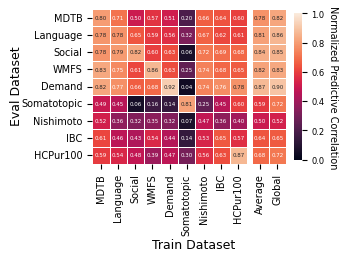

In [41]:
fig = plt.figure(figsize=(2.7, 2.3))
fig, ax1, ax2, cbar_ax = plu.plot_heatmap_annotate(df_L2reg, x_order=ds_order+["Average", "Global"], y_order=ds_order,
                                                   fig=fig, annot_kws={'fontsize': 4})
fig.supxlabel('Train Dataset', y=-0.22, fontsize=9)
fig.supylabel('Eval Dataset', x=-0.18, fontsize=9)
cbar_ax.set_label("Normalized Predictive Correlation", fontsize=7, rotation=270, labelpad=10)
ax1.tick_params(labelsize=7)
ax2.tick_params(labelsize=7)
cbar_ax.ax.tick_params(labelsize=6)

if save_plots:
    fig.savefig(gl.fig_dir + "/fig01_a.pdf", bbox_inches="tight", dpi=300)

In [43]:
pivot_L2reg = df_L2reg.pivot(index=['eval_dataset', 'eval_subj'], columns='train_dataset', values='R_eval_adj')

In [44]:
print(f"Same VS Average paired t-test results:")
print(f"\n{'Dataset':<15} {'dof':<10} {'t-stat':<10} {'p-value':<10} {'Sig':<10}")
print("=" * 55)

for ds in ds_order:
    df_average = pivot_L2reg[pivot_L2reg.index.get_level_values('eval_dataset') == ds]["Average"]
    df_same = pivot_L2reg[pivot_L2reg.index.get_level_values('eval_dataset') == ds][ds]

    t_stat, p_val = stats.ttest_rel(df_same, df_average, nan_policy='omit', alternative='greater')

    print(f"{ds:<15} {len(df_same)-1:<10} {t_stat:<10.3f} {p_val:<10.4f} {'Yes' if p_val < 0.05 else 'No':<10}")

print("-" * 55)
pivot_L2reg['Same'] = [row[eval_ds] for (eval_ds, _), row in pivot_L2reg.iterrows()]
t_stat_overall, p_val_overall = stats.ttest_rel(pivot_L2reg['Same'], pivot_L2reg['Average'], nan_policy='omit', alternative='greater')
print(f"{'Overall':<15} {len(pivot_L2reg['Same'])-1:<10} {t_stat_overall:<10.3f} {p_val_overall:<10.2e} {'Yes' if p_val_overall < 0.05 else 'No':<10}")

Same VS Average paired t-test results:

Dataset         dof        t-stat     p-value    Sig       
MDTB            23         2.551      0.0089     Yes       
Language        16         -2.352     0.9841     No        
Social          21         -0.883     0.8065     No        
WMFS            15         2.161      0.0236     Yes       
Demand          36         6.854      0.0000     Yes       
Somatotopic     7          4.846      0.0009     Yes       
Nishimoto       5          -0.919     0.7998     No        
IBC             11         0.218      0.4158     No        
HCPur100        49         9.532      0.0000     Yes       
-------------------------------------------------------
Overall         191        7.618      5.82e-13   Yes       


In [45]:
print(f"Average VS Best paired t-test results:")
print(f"\n{'Dataset':<15} {'Best_ds':<15} {'dof':<10} {'t-stat':<10} {'p-value':<10} {'Sig':<10}")
print("=" * 70)

best_ds_map = {}
for ds in ds_order:
    df_average = pivot_L2reg[pivot_L2reg.index.get_level_values('eval_dataset') == ds]["Average"]
    # find best dataset
    best_ds = (
        df_L2reg[
            (df_L2reg['train_dataset'].isin(ds_order)) &
            (df_L2reg['train_dataset'] != ds) &
            (df_L2reg['eval_dataset'] == ds)
        ]
        .groupby('train_dataset')['R_eval_adj']
        .mean()
        .idxmax()
    )
    best_ds_map[ds] = best_ds
    df_best = pivot_L2reg[pivot_L2reg.index.get_level_values('eval_dataset') == ds][best_ds]

    t_stat, p_val = stats.ttest_rel(df_average, df_best, nan_policy='omit', alternative='greater')
    print(f"{ds:<15} {best_ds:<15} {len(df_best)-1:<10} {t_stat:<10.3f} {p_val:<10.4f} {'Yes' if p_val < 0.05 else 'No':<10}")

print('-' * 70)
eval_ds = pivot_L2reg.index.get_level_values('eval_dataset')
pivot_L2reg['Best'] = pivot_L2reg.to_numpy()[
    np.arange(len(pivot_L2reg)),
    pivot_L2reg.columns.get_indexer(eval_ds.map(best_ds_map))
]
t_stat_overall, p_val_overall = stats.ttest_rel(pivot_L2reg['Average'], pivot_L2reg['Best'], nan_policy='omit', alternative='greater')
print(f"{'Overall':<15} {'':<15} {len(pivot_L2reg['Best'])-1:<10} {t_stat_overall:<10.3f} {p_val_overall:<10.2e} {'Yes' if p_val_overall < 0.05 else 'No':<10}")

Average VS Best paired t-test results:

Dataset         Best_ds         dof        t-stat     p-value    Sig       
MDTB            Language        23         11.176     0.0000     Yes       
Language        MDTB            16         2.694      0.0080     Yes       
Social          Language        21         2.699      0.0067     Yes       
WMFS            MDTB            15         -1.826     0.9561     No        
Demand          MDTB            36         6.952      0.0000     Yes       
Somatotopic     HCPur100        7          -0.572     0.7075     No        
Nishimoto       MDTB            5          -1.124     0.8439     No        
IBC             MDTB            11         2.494      0.0149     Yes       
HCPur100        IBC             49         4.540      0.0000     Yes       
----------------------------------------------------------------------
Overall                         191        8.501      2.66e-15   Yes       


In [46]:
print(f"Global VS Average paired t-test results:")
print(f"\n{'Dataset':<15} {'dof':<10} {'t-stat':<10} {'p-value':<10} {'Sig':<10}")
print("=" * 55)

for ds in ds_order:
    df_average = pivot_L2reg[pivot_L2reg.index.get_level_values('eval_dataset') == ds]["Average"]
    df_global = pivot_L2reg[pivot_L2reg.index.get_level_values('eval_dataset') == ds]["Global"]

    t_stat, p_val = stats.ttest_rel(df_global, df_average, nan_policy='omit', alternative='greater')
    print(f"{ds:<15} {len(df_global)-1:<10} {t_stat:<10.3f} {p_val:<10.4f} {'Yes' if p_val < 0.05 else 'No':<10}")

print('-' * 55)
t_stat_overall, p_val_overall = stats.ttest_rel(pivot_L2reg['Global'], pivot_L2reg['Average'], nan_policy='omit', alternative='greater')
print(f"{'Overall':<15} {len(pivot_L2reg['Global'])-1:<10} {t_stat_overall:<10.3f} {p_val_overall:<10.2e} {'Yes' if p_val_overall < 0.05 else 'No':<10}")

Global VS Average paired t-test results:

Dataset         dof        t-stat     p-value    Sig       
MDTB            23         6.790      0.0000     Yes       
Language        16         5.697      0.0000     Yes       
Social          21         1.506      0.0735     No        
WMFS            15         1.363      0.0965     No        
Demand          36         7.090      0.0000     Yes       
Somatotopic     7          6.210      0.0002     Yes       
Nishimoto       5          2.556      0.0254     Yes       
IBC             11         0.718      0.2439     No        
HCPur100        49         4.676      0.0000     Yes       
-------------------------------------------------------
Overall         191        9.944      2.43e-19   Yes       


#### ===========
####   PANEL B
#### ===========

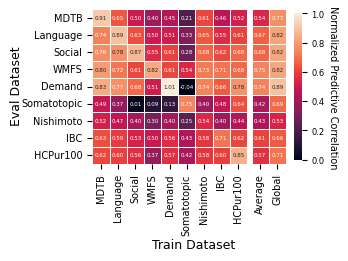

In [42]:
fig = plt.figure(figsize=(2.7, 2.3))
fig, ax1, ax2, cbar_ax = plu.plot_heatmap_annotate(df_NNLS, x_order=ds_order+["Average", "Global"], y_order=ds_order,
                                                   fig=fig, annot_kws={'fontsize': 4})
fig.supxlabel('Train Dataset', y=-0.22, fontsize=9)
fig.supylabel('Eval Dataset', x=-0.18, fontsize=9)
cbar_ax.set_label("Normalized Predictive Correlation", fontsize=7, rotation=270, labelpad=10)
ax1.tick_params(labelsize=7)
ax2.tick_params(labelsize=7)
cbar_ax.ax.tick_params(labelsize=6)

if save_plots:
    fig.savefig(gl.fig_dir + "/fig01_b.pdf", bbox_inches="tight", dpi=300)

In [47]:
pivot_NNLS = df_NNLS.pivot(index=['eval_dataset', 'eval_subj'], columns='train_dataset', values='R_eval_adj')

In [48]:
print(f"Same VS Average paired t-test results:")
print(f"\n{'Dataset':<15} {'dof':<10} {'t-stat':<10} {'p-value':<10} {'Sig':<10}")
print("=" * 55)

for ds in ds_order:
    df_average = pivot_NNLS[pivot_NNLS.index.get_level_values('eval_dataset') == ds]["Average"]
    df_same = pivot_NNLS[pivot_NNLS.index.get_level_values('eval_dataset') == ds][ds]

    t_stat, p_val = stats.ttest_rel(df_same, df_average, nan_policy='omit', alternative='greater')

    print(f"{ds:<15} {len(df_same)-1:<10} {t_stat:<10.3f} {p_val:<10.4f} {'Yes' if p_val < 0.05 else 'No':<10}")

print("-" * 55)
pivot_NNLS['Same'] = [row[eval_ds] for (eval_ds, _), row in pivot_NNLS.iterrows()]
t_stat_overall, p_val_overall = stats.ttest_rel(pivot_NNLS['Same'], pivot_NNLS['Average'], nan_policy='omit', alternative='greater')
print(f"{'Overall':<15} {len(pivot_NNLS['Same'])-1:<10} {t_stat_overall:<10.3f} {p_val_overall:<10.2e} {'Yes' if p_val_overall < 0.05 else 'No':<10}")

Same VS Average paired t-test results:

Dataset         dof        t-stat     p-value    Sig       
MDTB            23         16.482     0.0000     Yes       
Language        16         9.464      0.0000     Yes       
Social          21         5.126      0.0000     Yes       
WMFS            15         5.448      0.0000     Yes       
Demand          36         21.742     0.0000     Yes       
Somatotopic     7          7.511      0.0001     Yes       
Nishimoto       5          4.616      0.0029     Yes       
IBC             11         7.338      0.0000     Yes       
HCPur100        49         13.983     0.0000     Yes       
-------------------------------------------------------
Overall         191        23.825     2.07e-59   Yes       


In [49]:
print(f"Average VS Best paired t-test results:")
print(f"\n{'Dataset':<15} {'Best_ds':<15} {'dof':<10} {'t-stat':<10} {'p-value':<10} {'Sig':<10}")
print("=" * 70)

best_ds_map = {}
for ds in ds_order:
    df_average = pivot_NNLS[pivot_NNLS.index.get_level_values('eval_dataset') == ds]["Average"]
    # find best dataset
    best_ds = (
        df_NNLS[
            (df_NNLS['train_dataset'].isin(ds_order)) &
            (df_NNLS['train_dataset'] != ds) &
            (df_NNLS['eval_dataset'] == ds)
        ]
        .groupby('train_dataset')['R_eval_adj']
        .mean()
        .idxmax()
    )
    best_ds_map[ds] = best_ds
    df_best = pivot_NNLS[pivot_NNLS.index.get_level_values('eval_dataset') == ds][best_ds]

    t_stat, p_val = stats.ttest_rel(df_average, df_best, nan_policy='omit', alternative='greater')
    print(f"{ds:<15} {best_ds:<15} {len(df_best)-1:<10} {t_stat:<10.3f} {p_val:<10.4f} {'Yes' if p_val < 0.05 else 'No':<10}")

print('-' * 70)
eval_ds = pivot_NNLS.index.get_level_values('eval_dataset')
pivot_NNLS['Best'] = pivot_NNLS.to_numpy()[
    np.arange(len(pivot_NNLS)),
    pivot_NNLS.columns.get_indexer(eval_ds.map(best_ds_map))
]
t_stat_overall, p_val_overall = stats.ttest_rel(pivot_NNLS['Average'], pivot_NNLS['Best'], nan_policy='omit', alternative='greater')
print(f"{'Overall':<15} {'':<15} {len(pivot_NNLS['Best'])-1:<10} {t_stat_overall:<10.3f} {p_val_overall:<10.2e} {'Yes' if p_val_overall < 0.05 else 'No':<10}")

Average VS Best paired t-test results:

Dataset         Best_ds         dof        t-stat     p-value    Sig       
MDTB            Language        23         -10.284    1.0000     No        
Language        MDTB            16         -3.200     0.9972     No        
Social          Language        21         -6.314     1.0000     No        
WMFS            MDTB            15         -7.219     1.0000     No        
Demand          MDTB            36         -9.246     1.0000     No        
Somatotopic     HCPur100        7          -6.289     0.9998     No        
Nishimoto       MDTB            5          -5.914     0.9990     No        
IBC             MDTB            11         -2.634     0.9884     No        
HCPur100        MDTB            49         -6.272     1.0000     No        
----------------------------------------------------------------------
Overall                         191        -15.398    1.00e+00   No        


In [50]:
print(f"Global VS Average paired t-test results:")
print(f"\n{'Dataset':<15} {'dof':<10} {'t-stat':<10} {'p-value':<10} {'Sig':<10}")
print("=" * 55)

for ds in ds_order:
    df_average = pivot_NNLS[pivot_NNLS.index.get_level_values('eval_dataset') == ds]["Average"]
    df_global = pivot_NNLS[pivot_NNLS.index.get_level_values('eval_dataset') == ds]["Global"]

    t_stat, p_val = stats.ttest_rel(df_global, df_average, nan_policy='omit', alternative='greater')
    print(f"{ds:<15} {len(df_global)-1:<10} {t_stat:<10.3f} {p_val:<10.4f} {'Yes' if p_val < 0.05 else 'No':<10}")

print('-' * 55)
t_stat_overall, p_val_overall = stats.ttest_rel(pivot_NNLS['Global'], pivot_NNLS['Average'], nan_policy='omit', alternative='greater')
print(f"{'Overall':<15} {len(pivot_NNLS['Global'])-1:<10} {t_stat_overall:<10.3f} {p_val_overall:<10.2e} {'Yes' if p_val_overall < 0.05 else 'No':<10}")

Global VS Average paired t-test results:

Dataset         dof        t-stat     p-value    Sig       
MDTB            23         13.052     0.0000     Yes       
Language        16         6.943      0.0000     Yes       
Social          21         6.569      0.0000     Yes       
WMFS            15         5.297      0.0000     Yes       
Demand          36         16.116     0.0000     Yes       
Somatotopic     7          6.460      0.0002     Yes       
Nishimoto       5          6.040      0.0009     Yes       
IBC             11         4.599      0.0004     Yes       
HCPur100        49         11.448     0.0000     Yes       
-------------------------------------------------------
Overall         191        22.010     1.40e-54   Yes       


#### ===========
####   PANEL C
#### ===========

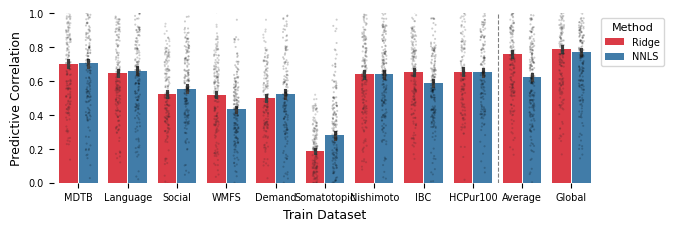

In [9]:
df_all = pd.concat([df_L2reg[df_L2reg.train_dataset != df_L2reg.eval_dataset],
                    df_NNLS[df_NNLS.train_dataset != df_NNLS.eval_dataset]]).reset_index(drop=True)

plt.figure(figsize=(7,2.2))
ax = plu.plot_barplot_with_error(df_all)
ax.set_ylim(0,1)
ax.set_ylabel('Predictive Correlation', fontsize=9)
ax.set_xlabel('Train Dataset', fontsize=9)
label_map = {'L2reg': 'Ridge', 'NNLS': 'NNLS'}
handles, labels = ax.get_legend_handles_labels()
new_labels = [label_map[l] for l in labels]
ax.legend(handles, new_labels, title='Method', bbox_to_anchor=(1.0, 1), loc='upper left', title_fontsize=8, fontsize=7)
ax.axvline(x=8.5, color='gray', linestyle='--', linewidth=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
sns.despine(left=True, bottom=True)
ax.tick_params(labelsize=7)

if save_plots:
    plt.savefig(gl.fig_dir + "/fig01_c.pdf", bbox_inches="tight", dpi=300)

In [4]:
print(f"Ridge VS NNLS paired t-test results:")
print(f"\n{'Dataset':<15} {'dof':<10} {'t-stat':<10} {'p-value':<10} {'Winner':<10}")
print("=" * 55)

df_all = pd.concat([df_L2reg, df_NNLS], axis=0).reset_index(drop=True)
pivot_all = df_all.pivot(index=["eval_dataset", "eval_subj"], 
                          columns=["train_dataset", "method"], values="R_eval_adj")

for ds in ds_order:
    df_sub_L2 = pivot_all[pivot_all.index.get_level_values("eval_dataset") != ds][(ds, "L2reg")]
    df_sub_NNLS = pivot_all[pivot_all.index.get_level_values("eval_dataset") != ds][(ds, "NNLS")]

    t_stat, p_val = stats.ttest_rel(df_sub_L2, df_sub_NNLS, nan_policy='omit')
    winner = '----' if p_val > 0.05 else ('Ridge' if t_stat > 0 else 'NNLS')
    print(f"{ds:<15} {len(df_sub_L2)-1:<10} {t_stat:<10.3f} {p_val:<10.2e} {winner:<10}")

print("-" * 55)
for ds in ["Average", "Global"]:
    df_sub_L2 = pivot_all[pivot_all.index.get_level_values("eval_dataset") != ds][(ds, "L2reg")]
    df_sub_NNLS = pivot_all[pivot_all.index.get_level_values("eval_dataset") != ds][(ds, "NNLS")]

    t_stat, p_val = stats.ttest_rel(df_sub_L2, df_sub_NNLS, nan_policy='omit', alternative='two-sided')
    winner = '----' if p_val > 0.05 else ('Ridge' if t_stat > 0 else 'NNLS')
    print(f"{ds:<15} {len(df_sub_L2)-1:<10} {t_stat:<10.3f} {p_val:<10.2e} {winner:<10}")


Ridge VS NNLS paired t-test results:

Dataset         dof        t-stat     p-value    Winner    
MDTB            167        -0.312     7.55e-01   ----      
Language        174        -0.952     3.42e-01   ----      
Social          169        -4.505     1.23e-05   NNLS      
WMFS            175        10.392     5.26e-20   Ridge     
Demand          154        -1.533     1.27e-01   ----      
Somatotopic     183        -6.165     4.39e-09   NNLS      
Nishimoto       185        -0.014     9.89e-01   ----      
IBC             179        5.788      3.12e-08   Ridge     
HCPur100        141        0.215      8.30e-01   ----      
-------------------------------------------------------
Average         191        13.864     1.07e-30   Ridge     
Global          191        2.709      7.36e-03   Ridge     


In [8]:
pivot_dataset = df_all.pivot_table(index="eval_dataset", columns=["train_dataset", "method"], values="R_eval_adj", aggfunc='mean')

print(f"Ridge VS NNLS paired t-test results (Dataset):")
print(f"\n{'Dataset':<15} {'dof':<10} {'t-stat':<10} {'p-value':<10} {'Winner':<10}")
print("=" * 55)
for ds in ["Average", "Global"]:
    df_sub_L2 = pivot_dataset[(ds, "L2reg")]
    df_sub_NNLS = pivot_dataset[(ds, "NNLS")]

    t_stat, p_val = stats.ttest_rel(df_sub_L2, df_sub_NNLS, nan_policy='omit', alternative='two-sided')
    winner = '----' if p_val > 0.05 else ('Ridge' if t_stat > 0 else 'NNLS')
    print(f"{ds:<15} {len(df_sub_L2)-1:<10} {t_stat:<10.3f} {p_val:<10.4f} {winner:<10}")

Ridge VS NNLS paired t-test results (Dataset):

Dataset         dof        t-stat     p-value    Winner    
Average         8          6.271      0.0002     Ridge     
Global          8          2.385      0.0442     Ridge     
